In [43]:
"""
pH visualization for coffee measurements (n = 18)
Translated from MATLAB to Python.

Layout: 9 measurements on the left are t1; 9 on the right are t2.
Each row is a cup, each column is a sensor.
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from scipy.stats import t as t_dist, norm

# --------- USER INPUT (EDIT THESE) ---------
ph = np.array([
    4.7, 5.2, 4.9,  5.0, 6.0, 5.1,
    4.7, 4.9, 5.0,  4.9, 5.5, 5.1,
    4.7, 4.9, 5.0,  4.9, 5.4, 5.1
])

cup    = np.array([1,1,1, 1,1,1, 2,2,2, 2,2,2, 3,3,3, 3,3,3])
sensor = np.array(['A','B','C','A','B','C','A','B','C',
                   'A','B','C','A','B','C','A','B','C'])
timept = np.array(['t1','t1','t1','t2','t2','t2','t1','t1','t1',
                   't2','t2','t2','t1','t1','t1','t2','t2','t2'])
# -------------------------------------------

assert len(ph) == len(cup) == len(sensor) == len(timept) == 18, \
    "All input arrays must have length 18."

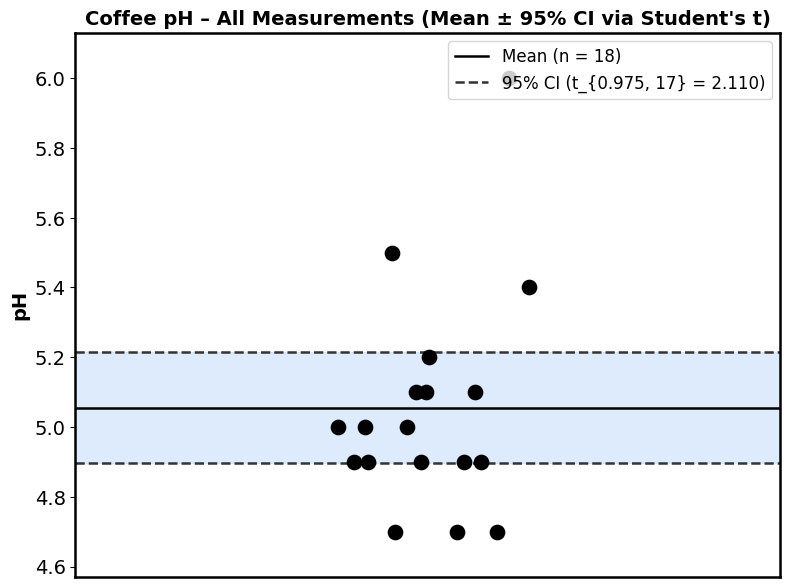

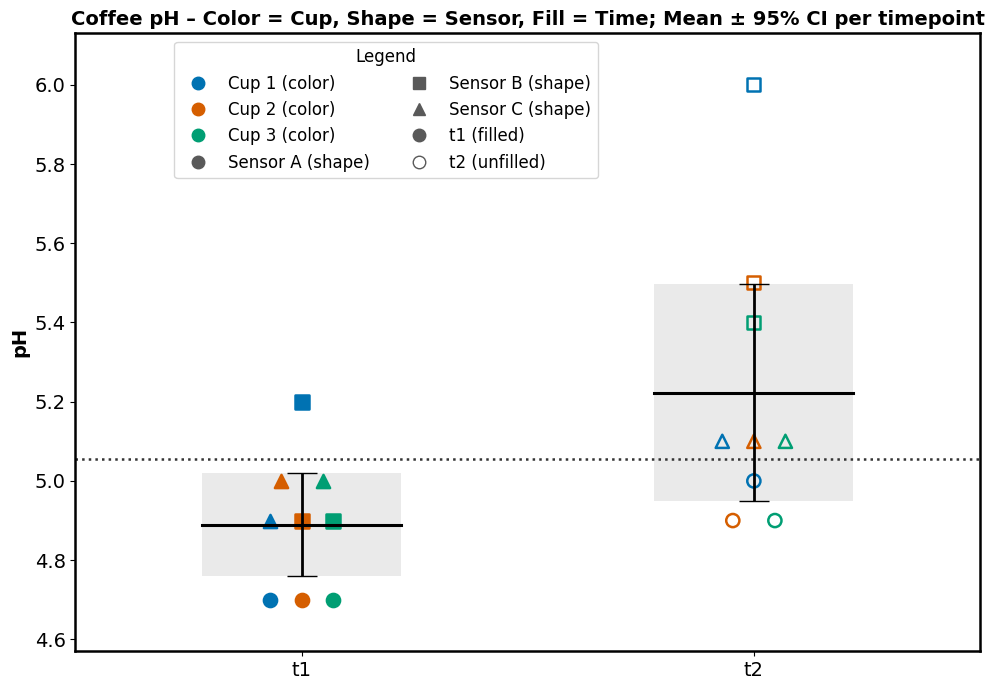

In [44]:
# ── Stats (Student's t, two-sided 95%) ──────────────────────────────────────
n   = len(ph)
mu  = np.mean(ph)
sd  = np.std(ph, ddof=1)          # sample std (denominator n-1)
se  = sd / np.sqrt(n)
df  = n - 1
t95 = t_dist.ppf(0.975, df)       # 95% two-sided critical value
ci  = t95 * se

# Y-limits with padding
ph_range = np.ptp(ph)
yl = [np.min(ph) - 0.1 * ph_range, np.max(ph) + 0.1 * ph_range]
if not all(np.isfinite(yl)) or yl[0] == yl[1]:
    yl = [np.min(ph) - 0.1, np.max(ph) + 0.1]

# ── Common plot settings ─────────────────────────────────────────────────────
ms  = 90    # marker size (points²)
lw  = 1.8
fsA = 14    # axis font size
fsL = 12    # legend font size
fsT = 14    # title font size

# Okabe & Ito colorblind-friendly palette
cup_colors = {
    1: np.array([0,   114, 178]) / 255,   # blue
    2: np.array([213,  94,   0]) / 255,   # vermillion
    3: np.array([  0, 158, 115]) / 255,   # bluish green
}

sensor_markers = {'A': 'o', 'B': 's', 'C': '^'}

rng = np.random.default_rng(67)   # reproducible jitter

# ── Figure 1: All data, mean ± 95% CI ────────────────────────────────────────
fig1, ax1 = plt.subplots(figsize=(8, 6), facecolor='white')

x_jitter = 1 + 0.08 * rng.standard_normal(n)
ax1.scatter(x_jitter, ph, s=ms, c='k', zorder=3, linewidths=lw)

# Shaded 95% CI band
ax1.axhspan(mu - ci, mu + ci, xmin=0, xmax=1,
            color=[0.75, 0.85, 0.98], alpha=0.5, zorder=1)

# Mean line
ax1.axhline(mu, color='black', linewidth=lw, zorder=2,
            label=f'Mean (n = {n})')

# CI dashed lines
ci_label = f'95% CI (t_{{0.975, {df}}} = {t95:.3f})'
ax1.axhline(mu - ci, color=[0.2, 0.2, 0.2], linewidth=lw,
            linestyle='--', zorder=2, label=ci_label)
ax1.axhline(mu + ci, color=[0.2, 0.2, 0.2], linewidth=lw,
            linestyle='--', zorder=2)

ax1.set_xlim(0.5, 1.5)
ax1.set_ylim(yl)
ax1.set_xticks([])
ax1.set_ylabel('pH', fontsize=fsA, fontweight='bold')
ax1.set_title(
    'Coffee pH – All Measurements (Mean ± 95% CI via Student\'s t)',
    fontsize=fsT, fontweight='bold'
)
ax1.legend(fontsize=fsL, loc='upper right')
ax1.tick_params(labelsize=fsA)
for spine in ax1.spines.values():
    spine.set_linewidth(lw)

fig1.tight_layout()

# ── Figure 2: t1 vs t2, per-timepoint mean ± CI ──────────────────────────────
fig2, ax2 = plt.subplots(figsize=(10, 7), facecolor='white')

# If any measurements at a timepoint are duplicated, spread them out horizontally to avoid overplotting
x = np.zeros(n)
for tp in ['t1', 't2']:
    t = 1 if tp == 't1' else 2

    # count occurrences of each measurement in this timepoint
    mask = timept == tp
    values, counts = np.unique(ph[mask], return_counts=True)
    for value, count in zip(values, counts):
        if count > 1:
            # indices of duplicates for this value and timepoint
            idxs = np.where(mask & (ph == value))[0]
            # normal offset values centered around 0
            offset = np.linspace(norm.ppf(0.01, 0, 0.01 * count),
                                norm.ppf(0.99, 0, 0.01 * count), count)
            x[idxs] = t + offset
        else:
            x[mask & (ph == value)] = t


# Scatter points
for i in range(n):
    color = cup_colors[cup[i]]
    mkr   = sensor_markers[sensor[i]]
    if timept[i] == 't1':
        ax2.scatter(x[i], ph[i], s=ms, marker=mkr,
                    facecolors=color, edgecolors=color,
                    linewidths=lw, zorder=3)
    else:
        ax2.scatter(x[i], ph[i], s=ms, marker=mkr,
                    facecolors='none', edgecolors=color,
                    linewidths=lw, zorder=3)

# Per-timepoint stats
def timepoint_stats(mask):
    vals = ph[mask]
    m    = np.mean(vals)
    s    = np.std(vals, ddof=1)
    se_  = s / np.sqrt(len(vals))
    ci_  = t_dist.ppf(0.975, len(vals) - 1) * se_
    return m, ci_

mask1 = timept == 't1'
mask2 = timept == 't2'
mu1, ci1 = timepoint_stats(mask1)
mu2, ci2 = timepoint_stats(mask2)

band_half = 0.22
ci_color  = [0.6, 0.6, 0.6]

# CI bands (behind points)
for xc, m, c in [(1, mu1, ci1), (2, mu2, ci2)]:
    rect = mpatches.FancyBboxPatch(
        (xc - band_half, m - c), 2 * band_half, 2 * c,
        boxstyle="square,pad=0",
        facecolor=ci_color, alpha=0.20, edgecolor='none', zorder=1
    )
    ax2.add_patch(rect)

# Mean tick lines
for xc, m in [(1, mu1), (2, mu2)]:
    ax2.plot([xc - band_half, xc + band_half], [m, m],
             '-', color='black', linewidth=2.2, zorder=4)

# Vertical error bars
ax2.errorbar([1, 2], [mu1, mu2], yerr=[ci1, ci2],
             fmt='none', color='black', linewidth=2.0,
             capsize=11, zorder=4)

# Overall mean dotted line
ax2.axhline(mu, color=[0.2, 0.2, 0.2], linewidth=lw, linestyle=':',
            label=f'Overall Mean (n = {n})', zorder=2)

ax2.set_xlim(0.5, 2.5)
ax2.set_ylim(yl)
ax2.set_xticks([1, 2])
ax2.set_xticklabels(['t1', 't2'])
ax2.set_ylabel('pH', fontsize=fsA, fontweight='bold')
ax2.set_title(
    'Coffee pH – Color = Cup, Shape = Sensor, Fill = Time; Mean ± 95% CI per timepoint',
    fontsize=fsT, fontweight='bold'
)
ax2.tick_params(labelsize=fsA)
for spine in ax2.spines.values():
    spine.set_linewidth(lw)

# ── Combined legend ───────────────────────────────────────────────────────────
neutral = [0.35, 0.35, 0.35]
legend_elements = [
    # Cups (color)
    Line2D([0],[0], marker='o', color='w',
           markerfacecolor=cup_colors[1], markeredgecolor=cup_colors[1],
           markersize=9, label='Cup 1 (color)'),
    Line2D([0],[0], marker='o', color='w',
           markerfacecolor=cup_colors[2], markeredgecolor=cup_colors[2],
           markersize=9, label='Cup 2 (color)'),
    Line2D([0],[0], marker='o', color='w',
           markerfacecolor=cup_colors[3], markeredgecolor=cup_colors[3],
           markersize=9, label='Cup 3 (color)'),
    # Sensors (shape)
    Line2D([0],[0], marker='o', color='w',
           markerfacecolor=neutral, markeredgecolor=neutral,
           markersize=9, label='Sensor A (shape)'),
    Line2D([0],[0], marker='s', color='w',
           markerfacecolor=neutral, markeredgecolor=neutral,
           markersize=9, label='Sensor B (shape)'),
    Line2D([0],[0], marker='^', color='w',
           markerfacecolor=neutral, markeredgecolor=neutral,
           markersize=9, label='Sensor C (shape)'),
    # Time (fill)
    Line2D([0],[0], marker='o', color='w',
           markerfacecolor=neutral, markeredgecolor=neutral,
           markersize=9, label='t1 (filled)'),
    Line2D([0],[0], marker='o', color='w',
           markerfacecolor='none', markeredgecolor=neutral,
           markersize=9, label='t2 (unfilled)'),
]

leg = ax2.legend(
    handles=legend_elements,
    ncol=2, loc='upper left', bbox_to_anchor=(0.1, 1),
    fontsize=fsL, frameon=True, title='Legend'
)
leg.get_title().set_fontsize(fsL)

fig2.tight_layout()
plt.show()